# (IIP314W-2) [2026-T2] OPTIMIZACIÓN APLICADA A NEGOCIOS
## Ayudantía 1: Puntos críticos y gradiente descendente — Pauta (Solución)

---

**Profesor:** Rodrigo Trigo Vilches

**Ayudante:** Vicente Ramírez

**Fecha:** 03 de junio de 2026

**Universidad del Desarrollo**

---

## Objetivos de la ayudantía

- Encontrar y clasificar **puntos críticos** en una y dos variables.
- Aplicar el **criterio de la segunda derivada** (1D) y el **Hessiano** (2D) para clasificar puntos críticos como mínimo, máximo o **punto silla**.
- Implementar el **descenso de gradiente** a mano y en código.
- Comparar el paso **normalizado** vs **no normalizado** y entender por qué afectan la convergencia.

## Repaso breve de conceptos

**Punto crítico (1D):** valor $x$ donde $f'(x)=0$. **Multivariable:** punto donde $\nabla f(x)=\mathbf{0}$.

**Criterio de la segunda derivada (1D):**
- Si $f''(x^*) < 0 \Rightarrow$ máximo local.
- Si $f''(x^*) > 0 \Rightarrow$ mínimo local.
- Si $f''(x^*) = 0 \Rightarrow$ no concluyente (posible inflexión).

**Criterio de segundo orden (2D, Hessiano):** con $D = \det H = f_{xx}f_{yy} - (f_{xy})^2$:
* si $D>0$ y $f_{xx}>0\Rightarrow$ mínimo.
* si $D>0$ y $f_{xx}<0\Rightarrow$ máximo.
* si $D<0\Rightarrow$ **punto silla**.
* si $D=0\Rightarrow$ no concluyente.

**Equivalencia max $\leftrightarrow$ min:** $\max f(x) = -\min(-f(x))$. La literatura trabaja siempre en minimización.

**Condición de primer orden multivariable:** el óptimo interior cumple $\nabla f = \mathbf{0}$.

**Descenso de gradiente — regla de actualización:**
$$x_{k+1} = x_k - \alpha\,\nabla f(x_k) \quad\text{(no normalizado)}$$
$$x_{k+1} = x_k - \alpha\,\frac{\nabla f(x_k)}{\lVert \nabla f(x_k)\rVert} \quad\text{(normalizado)}$$

**Criterio de parada:** $\lVert \nabla f(x_k)\rVert < \varepsilon$ (tolerancia) o alcanzar el máximo de iteraciones.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Ejercicio 1 — Fijación de precio (1 variable, puntos críticos)

Una empresa modela su utilidad (en millones de pesos) en función del precio unitario $p$ de su producto como:

$$U(p) = -3p^2 + 60p - 150$$

**Tareas:**
1. Encontrar el precio óptimo $p^*$ resolviendo $U'(p)=0$.
2. Clasificar el punto crítico con el criterio de la segunda derivada.
3. Calcular la utilidad máxima $U(p^*)$.
4. Graficar $U(p)$ en un rango razonable marcando el óptimo.

### Solución analítica

**Condición de primer orden:**
$$U'(p) = -6p + 60 = 0 \;\Rightarrow\; p^* = 10$$

**Criterio de la segunda derivada:**
$$U''(p) = -6 < 0 \;\Rightarrow\; \text{máximo}$$

**Utilidad máxima:**
$$U(10) = -3(10)^2 + 60(10) - 150 = -300 + 600 - 150 = 150$$

**Interpretación:** el precio que maximiza la utilidad es $p^* = 10$ (unidades monetarias por unidad de producto), generando una utilidad máxima de $150$ millones de pesos. Fijar un precio mayor o menor reduce la utilidad.

In [13]:
# Verificación simbólica con sympy
p = sp.symbols('p', real=True)
U = -3*p**2 + 60*p - 150

dU = sp.diff(U, p)        # primera derivada
d2U = sp.diff(U, p, 2)    # segunda derivada
p_opt = sp.solve(dU, p)[0]

print("U'(p)  =", dU)
print("U''(p) =", d2U)
print("p* =", p_opt)
print("Clasificacion:", "maximo" if d2U < 0 else "minimo")
print("U(p*) =", U.subs(p, p_opt))

U'(p)  = 60 - 6*p
U''(p) = -6
p* = 10
Clasificacion: maximo
U(p*) = 150


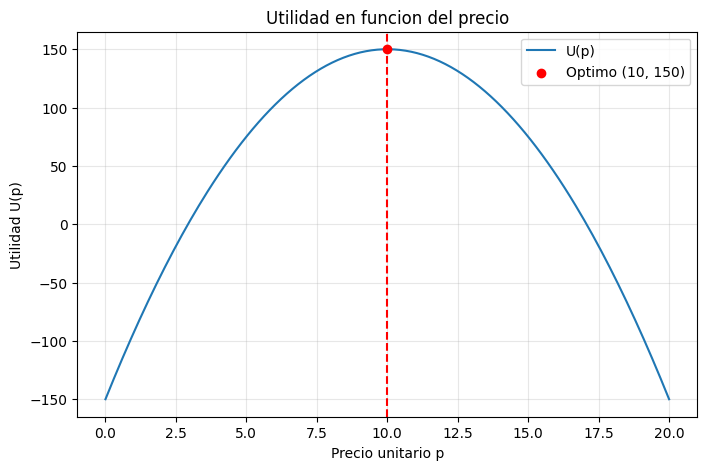

In [14]:
# Grafico de la utilidad
U_obj = lambda p: -3*p**2 + 60*p - 150
p_estrella = 10

p_vals = np.linspace(0, 20, 200)
plt.figure(figsize=(8, 5))
plt.plot(p_vals, U_obj(p_vals), label='U(p)')
plt.scatter([p_estrella], [U_obj(p_estrella)], color='red', zorder=5, label='Optimo (10, 150)')
plt.axvline(p_estrella, color='red', linestyle='--')
plt.xlabel('Precio unitario p')
plt.ylabel('Utilidad U(p)')
plt.title('Utilidad en funcion del precio')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Ejercicio 2 — Costo de producción (1 variable, gradiente descendente)

El costo de producción (en miles de pesos) de una planta en función de la cantidad producida $q$ (en miles de unidades) es:

$$C(q) = q^2 - 8q + 20$$

**Tareas:**
1. Encontrar analíticamente el mínimo resolviendo $C'(q)=0$.
2. Realizar **3 iteraciones de descenso de gradiente a mano** y mostrar los pasos en una tabla.
3. Implementar el descenso de gradiente en código y confirmar la convergencia a $q^*$.
4. Graficar la convergencia.

### (a) Solución analítica

$$C'(q) = 2q - 8 = 0 \;\Rightarrow\; q^* = 4$$
$$C''(q) = 2 > 0 \;\Rightarrow\; \text{mínimo}$$
$$C(4) = 4^2 - 8(4) + 20 = 16 - 32 + 20 = 4$$

El costo mínimo es $4$ (miles de pesos), alcanzado al producir $q^* = 4$ (miles de unidades).

### (b) Descenso de gradiente a mano

Usamos el **paso no normalizado** $q \leftarrow q - \alpha\,C'(q)$ con $q_0 = 0$ y $\alpha = 0.25$, donde $C'(q) = 2q - 8$.

| Iteración $k$ | $q_k$ | $C'(q_k) = 2q_k - 8$ | $q_{k+1} = q_k - 0.25\,C'(q_k)$ |
|:---:|:---:|:---:|:---:|
| 0 | 0.0 | $2(0)-8 = -8$ | $0 - 0.25(-8) = 2.0$ |
| 1 | 2.0 | $2(2)-8 = -4$ | $2 - 0.25(-4) = 3.0$ |
| 2 | 3.0 | $2(3)-8 = -2$ | $3 - 0.25(-2) = 3.5$ |
| 3 | 3.5 | $2(3.5)-8 = -1$ | $3.5 - 0.25(-1) = 3.75$ |

Tras 3 iteraciones llegamos a $q_3 = 3.5$ (y la siguiente sería $3.75$), acercándose progresivamente al óptimo $q^* = 4$. Notar que cada paso es más pequeño porque la derivada se achica al acercarnos al mínimo.

In [15]:
# (c) Implementacion del descenso de gradiente en 1D
C = lambda q: q**2 - 8*q + 20
dC = lambda q: 2*q - 8

def descenso_gradiente_1d(df, q0, alpha=0.25, tol=1e-6, max_iters=100):
    # in: derivada, punto inicial, tasa de aprendizaje, tolerancia, max iteraciones
    # out: minimo aproximado e historial de q
    q = q0
    historial = [q]
    for _ in range(max_iters):
        grad = df(q)
        if abs(grad) < tol:   # criterio de parada
            break
        q = q - alpha * grad
        historial.append(q)
    return q, historial

q_aprox, historial = descenso_gradiente_1d(dC, q0=0, alpha=0.25)
print("q* aproximado =", round(q_aprox, 6))
print("C(q*) =", round(C(q_aprox), 6))
print("Iteraciones =", len(historial) - 1)
print("Primeros pasos:", [round(v, 4) for v in historial[:5]])

q* aproximado = 4.0
C(q*) = 4.0
Iteraciones = 23
Primeros pasos: [0, 2.0, 3.0, 3.5, 3.75]


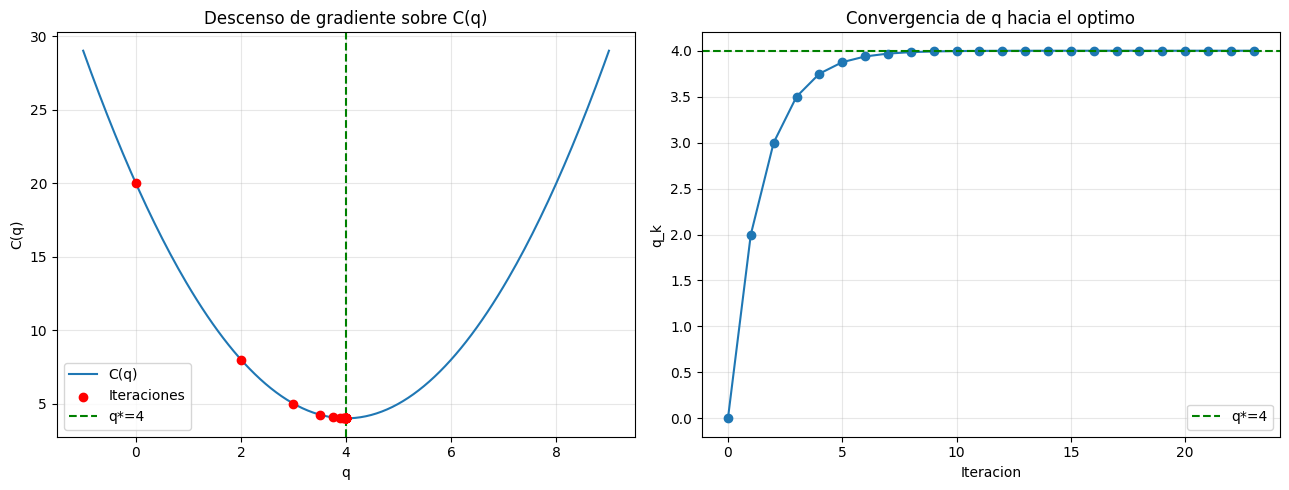

In [16]:
# (d) Grafico de la convergencia
q_vals = np.linspace(-1, 9, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: trayectoria sobre la funcion de costo
axes[0].plot(q_vals, C(q_vals), label='C(q)')
axes[0].scatter(historial, [C(q) for q in historial], color='red', zorder=5,
                label='Iteraciones')
axes[0].axvline(4, color='green', linestyle='--', label='q*=4')
axes[0].set_xlabel('q'); axes[0].set_ylabel('C(q)')
axes[0].set_title('Descenso de gradiente sobre C(q)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2: valor de q por iteracion
axes[1].plot(range(len(historial)), historial, marker='o')
axes[1].axhline(4, color='green', linestyle='--', label='q*=4')
axes[1].set_xlabel('Iteracion'); axes[1].set_ylabel('q_k')
axes[1].set_title('Convergencia de q hacia el optimo')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Ejercicio 3 — Ajuste de un modelo con dos hiperparámetros (puntos críticos, clasificación y descenso de gradiente)

El equipo de *analytics* de una empresa ajusta un modelo de demanda que depende de dos hiperparámetros $x$ e $y$. El **error de validación** (la función de pérdida que se busca minimizar) resultó ser:

$$L(x,y) = x^4 - 2x^2 + y^2 - 2y + 1$$

**Tareas:**
1. Encontrar **todos** los puntos críticos resolviendo $\nabla L = \mathbf{0}$.
2. Clasificar cada punto crítico (máximo, mínimo o **punto silla**) con el **Hessiano** (criterio de segundo orden en dos variables).
3. Determinar el mínimo global e indicar si es único.
4. Implementar el descenso de gradiente en 2D en **dos variantes** (paso **normalizado** y **no normalizado**) y comparar la convergencia.
5. Confirmar el óptimo con `scipy.optimize.minimize`.
6. Discutir qué ocurre si el descenso parte justo sobre el punto silla.

### (a) Puntos críticos: $\nabla L = \mathbf{0}$

El gradiente es:
$$\nabla L(x,y) = \left(\frac{\partial L}{\partial x},\, \frac{\partial L}{\partial y}\right) = \left(4x^3 - 4x,\; 2y - 2\right)$$

Igualando cada componente a cero:
$$4x^3 - 4x = 4x(x-1)(x+1) = 0 \;\Rightarrow\; x = 0,\; x = 1,\; x = -1$$
$$2y - 2 = 0 \;\Rightarrow\; y = 1$$

Hay **tres puntos críticos**:
$$P_1 = (0,\,1), \qquad P_2 = (1,\,1), \qquad P_3 = (-1,\,1)$$

### (b) Clasificación con el Hessiano

El Hessiano de $L$ es la matriz de segundas derivadas:
$$H(x,y) = \begin{pmatrix} L_{xx} & L_{xy} \\ L_{yx} & L_{yy} \end{pmatrix} = \begin{pmatrix} 12x^2 - 4 & 0 \\ 0 & 2 \end{pmatrix}$$

**Criterio de segundo orden (dos variables).** Con $D = \det H = L_{xx}L_{yy} - (L_{xy})^2$:
- $D > 0$ y $L_{xx} > 0 \;\Rightarrow\;$ mínimo local.
- $D > 0$ y $L_{xx} < 0 \;\Rightarrow\;$ máximo local.
- $D < 0 \;\Rightarrow\;$ **punto silla**.
- $D = 0 \;\Rightarrow\;$ no concluyente.

Aquí $D(x,y) = (12x^2 - 4)(2) - 0^2 = 24x^2 - 8$. Evaluando en cada punto crítico:

| Punto | $L_{xx} = 12x^2 - 4$ | $D = 24x^2 - 8$ | Clasificación | $L$ |
|:---:|:---:|:---:|:---:|:---:|
| $P_1 = (0,1)$ | $-4$ | $-8 < 0$ | **punto silla** | $0$ |
| $P_2 = (1,1)$ | $8$ | $16 > 0$ | **mínimo local** | $-1$ |
| $P_3 = (-1,1)$ | $8$ | $16 > 0$ | **mínimo local** | $-1$ |

### (c) Mínimo global

Completando cuadrados:
$$L(x,y) = \underbrace{(x^2 - 1)^2}_{\ge 0} \; - \; 1 \; + \; \underbrace{(y-1)^2}_{\ge 0}$$

Como $(x^2-1)^2 \ge 0$ y $(y-1)^2 \ge 0$, se cumple $L(x,y) \ge -1$, con igualdad **solo** cuando $x^2 = 1$ e $y = 1$. Por lo tanto:

- El **valor mínimo global es $-1$**.
- Se alcanza en **dos puntos**: $(1,1)$ y $(-1,1)$. El mínimo global **no es único** (hay dos configuraciones de hiperparámetros igual de buenas).
- $(0,1)$ es un **punto silla**: en la dirección $x$ es un máximo y en la dirección $y$ un mínimo, por eso no es óptimo.

In [17]:
# Verificacion simbolica: puntos criticos, Hessiano y clasificacion
x, y = sp.symbols('x y', real=True)
L_sym = x**4 - 2*x**2 + y**2 - 2*y + 1

grad_sym = [sp.diff(L_sym, x), sp.diff(L_sym, y)]
criticos = sp.solve(grad_sym, (x, y), dict=True)
H = sp.hessian(L_sym, (x, y))

print("Gradiente:", grad_sym)
print("Hessiano:", H.tolist())
print()
for sol in criticos:
    Hp = H.subs(sol)
    D = Hp.det()
    Lxx = Hp[0, 0]
    if D < 0:
        tipo = "punto silla"
    elif D > 0 and Lxx > 0:
        tipo = "minimo local"
    elif D > 0 and Lxx < 0:
        tipo = "maximo local"
    else:
        tipo = "no concluyente"
    print(f"({sol[x]}, {sol[y]}): Lxx={Lxx}, D={D}  ->  {tipo}, L={L_sym.subs(sol)}")

Gradiente: [4*x**3 - 4*x, 2*y - 2]
Hessiano: [[12*x**2 - 4, 0], [0, 2]]

(-1, 1): Lxx=8, D=16  ->  minimo local, L=-1
(0, 1): Lxx=-4, D=-8  ->  punto silla, L=0
(1, 1): Lxx=8, D=16  ->  minimo local, L=-1


In [18]:
# (d) Descenso de gradiente en 2D: variantes normalizada y no normalizada
L = lambda x, y: x**4 - 2*x**2 + y**2 - 2*y + 1
gradiente = lambda x, y: np.array([4*x**3 - 4*x, 2*y - 2])

def descenso_gradiente_2d(grad_fn, X0, alpha, normalizado=False,
                          tol=1e-3, max_iters=1000):
    # in: gradiente, punto inicial, tasa, flag normalizado, tolerancia, max iters
    # out: punto final, historial, numero de iteraciones
    X = np.array(X0, dtype=float)
    historial = [X.copy()]
    iteracion = 0
    for iteracion in range(1, max_iters + 1):
        g = grad_fn(X[0], X[1])
        if np.linalg.norm(g) < tol:   # criterio de parada
            break
        paso = g / np.linalg.norm(g) if normalizado else g
        X = X - alpha * paso
        historial.append(X.copy())
    return X, np.array(historial), iteracion

X0 = (0.5, 0.5)   # partimos en la cuenca del minimo (1, 1)
alpha = 0.1

X_norm, hist_norm, it_norm = descenso_gradiente_2d(gradiente, X0, alpha, normalizado=True)
X_nonorm, hist_nonorm, it_nonorm = descenso_gradiente_2d(gradiente, X0, alpha, normalizado=False)

print("NORMALIZADO    -> punto:", np.round(X_norm, 4), "| L:", round(L(*X_norm), 4),
      "| iters:", it_norm)
print("NO NORMALIZADO -> punto:", np.round(X_nonorm, 4), "| L:", round(L(*X_nonorm), 4),
      "| iters:", it_nonorm)

NORMALIZADO    -> punto: [1.0245 1.    ] | L: -0.9975 | iters: 1000
NO NORMALIZADO -> punto: [1.     0.9995] | L: -1.0 | iters: 32


In [19]:
# Distancia al minimo global mas cercano (1, 1)
optimo = np.array([1.0, 1.0])
print("Distancia al minimo (normalizado)   :", round(np.linalg.norm(X_norm - optimo), 4))
print("Distancia al minimo (no normalizado):", round(np.linalg.norm(X_nonorm - optimo), 6))

Distancia al minimo (normalizado)   : 0.0245
Distancia al minimo (no normalizado): 0.000495


In [20]:
# (e) Confirmacion con scipy.optimize.minimize (Nelder-Mead, como en la Clase 3)
from scipy.optimize import minimize

L_obj = lambda v: v[0]**4 - 2*v[0]**2 + v[1]**2 - 2*v[1] + 1

res_der = minimize(L_obj, x0=[0.5, 0.5], method='Nelder-Mead')   # cuenca derecha (x>0)
res_izq = minimize(L_obj, x0=[-0.5, 0.5], method='Nelder-Mead')  # cuenca izquierda (x<0)

print("Desde ( 0.5, 0.5):  x* =", np.round(res_der.x, 4), "| L* =", round(res_der.fun, 6))
print("Desde (-0.5, 0.5):  x* =", np.round(res_izq.x, 4), "| L* =", round(res_izq.fun, 6))
print("\nscipy confirma los DOS minimos globales (1,1) y (-1,1), ambos con L = -1,")
print("segun desde que cuenca parta la busqueda.")

Desde ( 0.5, 0.5):  x* = [1. 1.] | L* = -1.0
Desde (-0.5, 0.5):  x* = [-1.  1.] | L* = -1.0

scipy confirma los DOS minimos globales (1,1) y (-1,1), ambos con L = -1,
segun desde que cuenca parta la busqueda.


### (d) Tabla comparativa del descenso de gradiente

(Valores con $\alpha = 0.1$, $X_0=(0.5,\,0.5)$, $\varepsilon = 10^{-3}$, máx. 1000 iteraciones. Resultados verificados ejecutando el código.)

| Variante | Punto inicial | Iteraciones | Mínimo hallado $(x,y)$ | $L$ hallado | Óptimo real | Distancia al óptimo |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| Normalizado | $(0.5,\,0.5)$ | 1000 (máx.) | $(1.0245,\ 1.0000)$ | $-0.9975$ | $(1,1)$ | $0.0245$ |
| No normalizado | $(0.5,\,0.5)$ | $32$ | $(1.0000,\ 0.9995)$ | $-1.0000$ | $(1,1)$ | $0.0005$ |

*Nota:* el paso **no normalizado converge** al mínimo $(1,1)$ en 32 iteraciones (se detiene por la tolerancia $\lVert\nabla L\rVert<\varepsilon$). El paso **normalizado no converge**: agota las 1000 iteraciones y queda **oscilando alrededor de $(1,1)$ a una distancia del orden de $\alpha$**, porque el paso de tamaño fijo no se achica al acercarse al óptimo. El cálculo es determinístico, así que estos valores se reproducen idénticos en cada corrida.

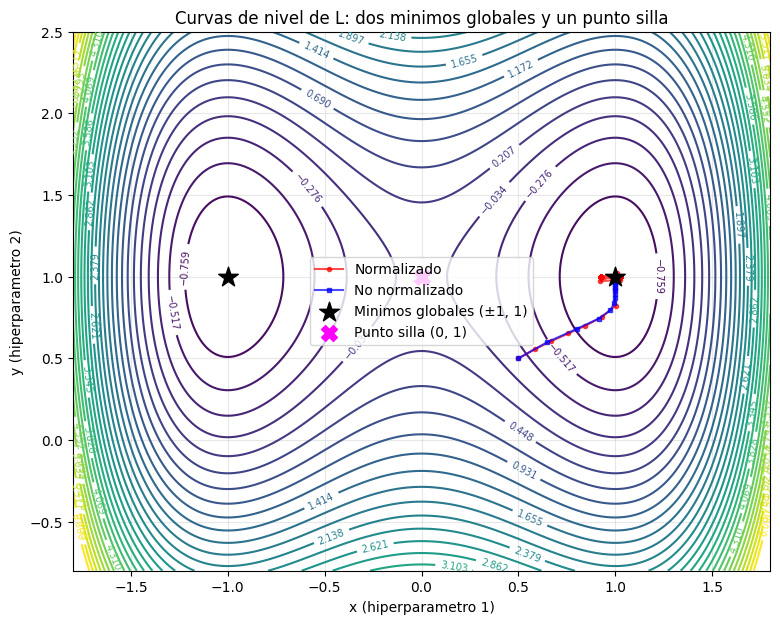

In [21]:
# (f) Curvas de nivel con las tres soluciones y ambas trayectorias
x_vals = np.linspace(-1.8, 1.8, 400)
y_vals = np.linspace(-0.8, 2.5, 400)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z_grid = L(X_grid, Y_grid)

plt.figure(figsize=(9, 7))
niveles = np.linspace(Z_grid.min(), 6, 30)
cs = plt.contour(X_grid, Y_grid, Z_grid, levels=niveles, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=7)

plt.plot(hist_norm[:, 0], hist_norm[:, 1], 'o-', color='red', markersize=3,
         label='Normalizado', alpha=0.7)
plt.plot(hist_nonorm[:, 0], hist_nonorm[:, 1], 's-', color='blue', markersize=3,
         label='No normalizado', alpha=0.7)
plt.scatter([1, -1], [1, 1], color='black', marker='*', s=220, zorder=5,
            label='Minimos globales (±1, 1)')
plt.scatter([0], [1], color='magenta', marker='X', s=130, zorder=5,
            label='Punto silla (0, 1)')

plt.xlabel('x (hiperparametro 1)'); plt.ylabel('y (hiperparametro 2)')
plt.title('Curvas de nivel de L: dos minimos globales y un punto silla')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# (g) Que pasa si partimos justo sobre la cresta x = 0 (hacia el punto silla)
X_silla, hist_silla, it_silla = descenso_gradiente_2d(gradiente, (0.0, 0.5), alpha,
                                                      normalizado=False)
print("Partiendo de (0, 0.5):", np.round(X_silla, 4), "| L:", round(L(*X_silla), 4),
      "| iters:", it_silla)
print("-> El gradiente en x vale 0 sobre la cresta y se mantiene en 0:")
print("   el descenso queda ATRAPADO en el PUNTO SILLA (0, 1), no en un minimo.")

Partiendo de (0, 0.5): [0.     0.9995] | L: 0.0 | iters: 32
-> El gradiente en x vale 0 sobre la cresta y se mantiene en 0:
   el descenso queda ATRAPADO en el PUNTO SILLA (0, 1), no en un minimo.


### (e) Discusión

**Clasificación de puntos críticos (lo nuevo de la Clase 3).** No basta con $\nabla L = \mathbf{0}$: un punto crítico puede ser mínimo, máximo o **punto silla**. El Hessiano (criterio de segundo orden) los distingue. Aquí $(\pm 1, 1)$ son mínimos globales —ambos con $L=-1$— y $(0,1)$ es un punto silla: en la dirección $x$ es un máximo y en la dirección $y$ un mínimo, por eso $D = \det H < 0$.

**Normalizado vs. no normalizado (lo de la Clase 2).** Igual que en el ejercicio anterior:
- El **paso no normalizado** $X \leftarrow X - \alpha\,\nabla L$ se achica solo al acercarse al óptimo ($\nabla L \to \mathbf{0}$) y aterriza en $(1,1)$, deteniéndose por tolerancia.
- El **paso normalizado** $X \leftarrow X - \alpha\,\dfrac{\nabla L}{\lVert\nabla L\rVert}$ mantiene longitud fija $\alpha$ y se queda oscilando alrededor de $(1,1)$ a una distancia del orden de $\alpha$, agotando las iteraciones.

**Cuidado con los puntos silla.** Si el descenso parte justo sobre la cresta $x=0$, la componente $x$ del gradiente es $0$ y se mantiene en $0$: el método se desliza hasta el **punto silla** $(0,1)$ y se detiene ahí, sin alcanzar ningún mínimo. Por eso en la práctica conviene (i) inicializar de forma aleatoria o perturbada y (ii) **verificar con el criterio de segundo orden** que el punto hallado es realmente un mínimo. `scipy.optimize.minimize` encuentra uno u otro mínimo global según la cuenca de partida, confirmando que hay **dos** soluciones óptimas.